# Asymmetric Constraint Contours

It does:
1. fits the symmetric ground state for `vdw`, `cs`, and `tvm`
2. scans the ratio plane at fixed fitted averages $a=(a_n+a_{pn})/2$ and $b=(b_n+b_{pn})/2$
3. evaluates `J` and `L` with `qmm.asymmetry`
4. plots the $J=30-35$ MeV band and the $L=58.9$ MeV line
5. overlays the existing `equal_b` and `target_l` solutions

The goal is a qualitative reproduction with the present QMM implementation, not a claim of exact digit-by-digit agreement with the published figure.

In [1]:
from pathlib import Path
import math
import sys

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch

candidate_roots = []
seen = set()
for base in [Path.cwd(), *Path.cwd().parents]:
    for candidate in (base, base / "QMM"):
        resolved = candidate.resolve()
        marker = str(resolved)
        if marker not in seen:
            seen.add(marker)
            candidate_roots.append(resolved)

ROOT = None
for candidate in candidate_roots:
    if (candidate / "src" / "qmm").exists() and (candidate / "examples").exists():
        ROOT = candidate
        break

if ROOT is None:
    raise RuntimeError("Could not locate the QMM root from this notebook.")

SRC_DIR = ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from qmm.asymmetry import compute_asymmetric_fit, symmetry_energy_parabolic, symmetry_slope_l
from qmm.constants import AsymmetricFitSettings, DEFAULT_GROUND_STATE_SETTINGS, DEFAULT_PHYSICAL_CONSTANTS
from qmm.ground_state import compute_ground_state_point

OUTPUT_DIR = ROOT / "results" / "generated" / "asymmetric_constraint_contours"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f"QMM root: {ROOT}")
print(f"Output directory: {OUTPUT_DIR.relative_to(ROOT)}")

QMM root: /Users/dajuarez4/Documents/QuarkMatt/good_repo/QMM
Output directory: results/generated/asymmetric_constraint_contours


In [2]:
MODEL_STYLES = {
    "vdw": {"label": "van der Waals", "color": "#7f7f7f", "alpha": 0.34, "linestyle": "-"},
    "cs": {"label": "Carnahan-Starling", "color": "#1f77b4", "alpha": 0.24, "linestyle": "-"},
    "tvm": {"label": "trivial model (TVM)", "color": "#ff6b6b", "alpha": 0.22, "linestyle": "-"},
}

J_TARGET = 32.5
J_HALF_WIDTH = 2.5
J_MIN = J_TARGET - J_HALF_WIDTH
J_MAX = J_TARGET + J_HALF_WIDTH
L_TARGET = 58.9

RB_MIN, RB_MAX, RB_POINTS = 0.02, 2.35, 180
RA_MIN, RA_MAX, RA_POINTS = 0.02, 3.10, 220

FIT_SETTINGS = AsymmetricFitSettings(
    enabled=True,
    target_j=J_TARGET,
    target_l=L_TARGET,
    derivative_step_l=1.0e-4,
)

rb_values = np.linspace(RB_MIN, RB_MAX, RB_POINTS)
ra_values = np.linspace(RA_MIN, RA_MAX, RA_POINTS)
rb_grid, ra_grid = np.meshgrid(rb_values, ra_values)

print(f"Grid shape: {ra_grid.shape}")
print(f"J band: [{J_MIN:.1f}, {J_MAX:.1f}] MeV")
print(f"Target L: {L_TARGET:.1f} MeV")

Grid shape: (220, 180)
J band: [30.0, 35.0] MeV
Target L: 58.9 MeV


In [3]:
def split_from_ratio(avg_value, ratio):
    ratio = float(ratio)
    if ratio <= 0.0:
        return None, None
    delta = avg_value * (ratio - 1.0) / (ratio + 1.0)
    left = avg_value - delta
    right = avg_value + delta
    if left <= 0.0 or right <= 0.0:
        return None, None
    return left, right


def evaluate_ratio_point(model_name, ground_state, ratio_b, ratio_a):
    a_n, a_pn = split_from_ratio(ground_state.a, ratio_a)
    b_n, b_pn = split_from_ratio(ground_state.b, ratio_b)
    if None in (a_n, a_pn, b_n, b_pn):
        return math.nan, math.nan

    j_value = symmetry_energy_parabolic(
        model_name,
        DEFAULT_PHYSICAL_CONSTANTS.n0,
        a_n,
        a_pn,
        b_n,
        b_pn,
        ground_state.parameter_value,
        DEFAULT_PHYSICAL_CONSTANTS,
        DEFAULT_GROUND_STATE_SETTINGS,
    )
    if j_value is None or not math.isfinite(j_value):
        return math.nan, math.nan

    l_value = symmetry_slope_l(
        model_name,
        a_n,
        a_pn,
        b_n,
        b_pn,
        ground_state.parameter_value,
        DEFAULT_PHYSICAL_CONSTANTS,
        FIT_SETTINGS,
        DEFAULT_GROUND_STATE_SETTINGS,
    )
    if not math.isfinite(l_value):
        return j_value, math.nan
    return j_value, l_value


def scan_ratio_plane(model_name):
    ground_state = compute_ground_state_point(model_name)
    j_grid = np.full(rb_grid.shape, np.nan, dtype=float)
    l_grid = np.full(rb_grid.shape, np.nan, dtype=float)

    for i, ratio_a in enumerate(ra_values):
        for j, ratio_b in enumerate(rb_values):
            j_value, l_value = evaluate_ratio_point(model_name, ground_state, ratio_b, ratio_a)
            j_grid[i, j] = j_value
            l_grid[i, j] = l_value

    equal_b_fit = compute_asymmetric_fit(
        model_name=model_name,
        fit_settings=AsymmetricFitSettings(
            enabled=True,
            branch_mode="equal_b",
            target_j=J_TARGET,
            target_l=L_TARGET,
            derivative_step_l=FIT_SETTINGS.derivative_step_l,
        ),
    )
    target_l_fit = compute_asymmetric_fit(
        model_name=model_name,
        fit_settings=AsymmetricFitSettings(
            enabled=True,
            branch_mode="target_l",
            target_j=J_TARGET,
            target_l=L_TARGET,
            derivative_step_l=FIT_SETTINGS.derivative_step_l,
        ),
    )

    return {
        "ground_state": ground_state,
        "J": j_grid,
        "L": l_grid,
        "equal_b": equal_b_fit,
        "target_l": target_l_fit,
    }


scans = {model_name: scan_ratio_plane(model_name) for model_name in MODEL_STYLES}
print("Finished scanning the ratio plane for:", ", ".join(MODEL_STYLES))

Finished scanning the ratio plane for: vdw, cs, tvm


In [4]:
summary_rows = []
for model_name, style in MODEL_STYLES.items():
    block = scans[model_name]
    equal_b = block["equal_b"]
    target_l = block["target_l"]
    summary_rows.append(
        {
            "model": style["label"],
            "K0 [MeV]": round(equal_b.K0, 3),
            "a_avg": round(equal_b.a_avg, 6),
            "b_avg": round(equal_b.b_avg, 6),
            "equal_b: a_pn/a_n": round(equal_b.ratio_a_pn_over_a_n, 6),
            "equal_b: b_pn/b_n": round(equal_b.ratio_b_pn_over_b_n, 6),
            "target_l: a_pn/a_n": round(target_l.ratio_a_pn_over_a_n, 6),
            "target_l: b_pn/b_n": round(target_l.ratio_b_pn_over_b_n, 6),
            "target_l: J": round(target_l.J, 6),
            "target_l: L": round(target_l.L, 6),
        }
    )

try:
    import pandas as pd

    display(pd.DataFrame(summary_rows))
except Exception:
    from pprint import pprint

    pprint(summary_rows)

,model,K0 [MeV],a_avg,b_avg,equal_b: a_pn/a_n,equal_b: b_pn/b_n,target_l: a_pn/a_n,target_l: b_pn/b_n,target_l: J,target_l: L
0,van der Waals,762.539,328.923321,3.414020,1.572847,1.0,2.392092,1.785622,32.5,58.9
1,Carnahan-Starling,601.449,347.017219,4.426715,1.446457,1.0,2.399611,2.014892,32.5,58.9
2,trivial model (TVM),564.221,349.009326,4.280134,1.434075,1.0,2.438056,2.075809,32.5,58.9


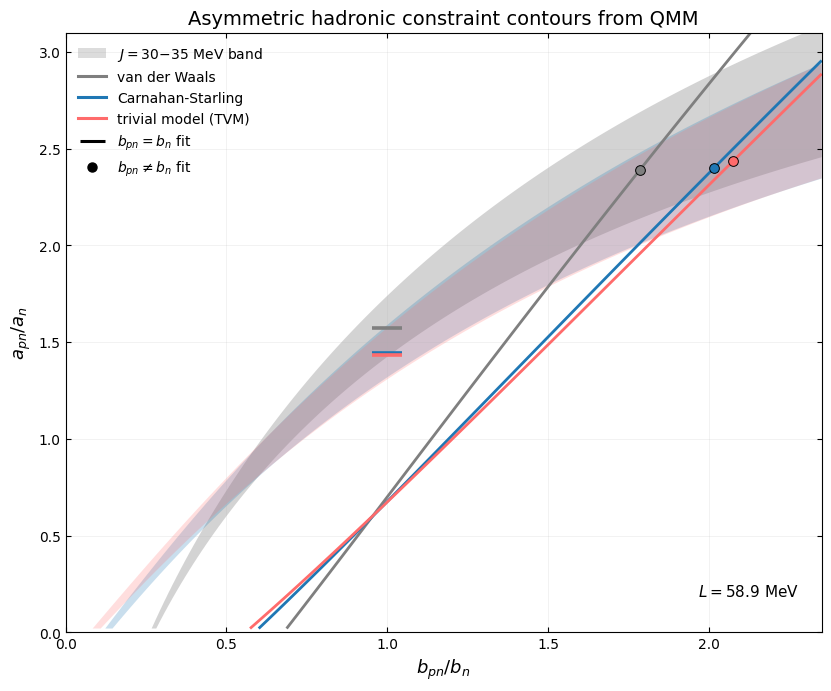

Saved: results/generated/asymmetric_constraint_contours/asymmetric_constraint_contours.png
Saved: results/generated/asymmetric_constraint_contours/asymmetric_constraint_contours.pdf


In [5]:
fig, ax = plt.subplots(figsize=(8.2, 6.8), constrained_layout=True)

for model_name, style in MODEL_STYLES.items():
    block = scans[model_name]
    j_masked = np.ma.masked_invalid(block["J"])
    l_masked = np.ma.masked_invalid(block["L"])

    ax.contourf(
        rb_grid,
        ra_grid,
        j_masked,
        levels=[J_MIN, J_MAX],
        colors=[style["color"]],
        alpha=style["alpha"],
        antialiased=True,
    )
    ax.contour(
        rb_grid,
        ra_grid,
        l_masked,
        levels=[L_TARGET],
        colors=[style["color"]],
        linewidths=2.0,
        linestyles=style["linestyle"],
    )

    equal_b = block["equal_b"]
    target_l = block["target_l"]
    ax.plot(
        equal_b.ratio_b_pn_over_b_n,
        equal_b.ratio_a_pn_over_a_n,
        marker="_",
        markersize=22,
        markeredgewidth=2.6,
        color=style["color"],
        linestyle="None",
    )
    ax.plot(
        target_l.ratio_b_pn_over_b_n,
        target_l.ratio_a_pn_over_a_n,
        marker="o",
        markersize=7.0,
        markerfacecolor=style["color"],
        markeredgecolor="black",
        markeredgewidth=0.7,
        linestyle="None",
    )

legend_handles = [
    Patch(facecolor="#8c8c8c", edgecolor="none", alpha=0.30, label=r"$J=30\!-\!35$ MeV band"),
]
legend_handles.extend(
    Line2D([0], [0], color=style["color"], lw=2.2, label=style["label"])
    for style in MODEL_STYLES.values()
)
legend_handles.extend(
    [
        Line2D([0], [0], color="black", marker="_", linestyle="None", markersize=18, markeredgewidth=2.2, label=r"$b_{pn}=b_n$ fit"),
        Line2D([0], [0], color="black", marker="o", linestyle="None", markersize=6.5, label=r"$b_{pn}\neq b_n$ fit"),
    ]
)

ax.legend(handles=legend_handles, loc="upper left", frameon=False, fontsize=10)
ax.set_xlim(0.0, RB_MAX)
ax.set_ylim(0.0, RA_MAX)
ax.set_xlabel(r"$b_{pn}/b_n$", fontsize=13)
ax.set_ylabel(r"$a_{pn}/a_n$", fontsize=13)
ax.set_title("Asymmetric hadronic constraint contours from QMM", fontsize=14)
ax.grid(alpha=0.18, linewidth=0.6)
ax.tick_params(direction="in", top=True, right=True)
ax.text(0.97, 0.06, r"$L=58.9$ MeV", transform=ax.transAxes, ha="right", fontsize=11)

figure_png = OUTPUT_DIR / "asymmetric_constraint_contours.png"
figure_pdf = OUTPUT_DIR / "asymmetric_constraint_contours.pdf"
fig.savefig(figure_png, dpi=240)
fig.savefig(figure_pdf)
plt.show()

print(f"Saved: {figure_png.relative_to(ROOT)}")
print(f"Saved: {figure_pdf.relative_to(ROOT)}")